In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## RDM policies 

In [1]:
import pandas as pd

# Load your dataset
dataset = pd.read_csv("/Users/pedrohserrano/uncovering-rdm-policies-through-topic-modeling/data/output/corpus_of_value_propositions_in_rdm_policies.csv")

### Quick overview

In [2]:
# Total unique identifiers for % calculation
total_unique_chunks = dataset["policy_chunk"].nunique()

def pretty_label(s: str) -> str:
    """snake_case -> Title Case with spaces"""
    return s.replace("_", " ").title()

def summarize_column(col: str) -> pd.DataFrame:
    """
    For a given column, count unique policy_chunk values,
    sort by count desc, and add relative % of total unique policy_chunk.
    """
    out = (
        dataset.groupby(col)["policy_chunk"]
               .nunique()
               .reset_index()
               .sort_values("policy_chunk", ascending=False)
    )
    # Rename columns
    out.columns = [pretty_label(col), "Count"]
    # Percentage relative to ALL unique policy_chunk
    out["%"] = (out["Count"] / total_unique_chunks * 100).round(2)
    return out

# Run summaries for each non-id column
for col in [c for c in dataset.columns if c != "policy_chunk"]:
    print(f"\n=== {pretty_label(col)} ===")
    display(summarize_column(col))

# Optional: a compact overview of how many categories per column
overview = (
    dataset.drop(columns=["policy_chunk"])
           .nunique()
           .reset_index()
)
overview.columns = ["Column", "Distinct Categories"]
overview["Column"] = overview["Column"].apply(pretty_label)
display(overview)


=== Section ===


,Section,Count,%
5,Preamble / Introduction / Background,38,26.03
2,General provisions / Guiding principles,28,19.18
9,"Retention, Archiving, & Disposal",16,10.96
10,Roles & Responsibilities,14,9.59
1,Ensuring access / Sharing,12,8.22
7,Purpose / Objective,9,6.16
12,Scope & Definitions,9,6.16
13,Storage / Safeguarding / Backup,5,3.42
0,Data Management Plan,4,2.74
3,IP commercialization / Knowledge transfer,4,2.74



=== Value Target ===


,Value Target,Count,%
1,data,122,83.56
0,associated materials,12,8.22
6,research outputs,8,5.48
2,data management,6,4.11
3,policy,3,2.05
5,research,3,2.05
7,values (societal/ethical),3,2.05
4,repository,1,0.68



=== Value Condition Declaration ===


...


=== Value Proposition Short ===


,Value Proposition Short,Count,%
35,"data, if long-term value, should be preserved",17,11.64
23,"data, if best practices are followed, value is...",9,6.16
39,"data, if long-term value, should remain access...",9,6.16
36,"data, if long-term value, should be published/...",9,6.16
42,"data, if substantiates published findings, sho...",8,5.48
...,...,...,...
1,"associated materials, if continuing value, sho...",1,0.68
45,"data, if substantiates published findings, sho...",1,0.68
50,"data, if valuable, should be retained",1,0.68
51,"data, if valuable, should follow institutional...",1,0.68



=== Value Proposition Long ===


,Value Proposition Long,Count,%
69,"data, if long-term value, should be preserved ...",8,5.48
86,"data, if no further value, should be destroyed...",6,4.11
78,"data, if long-term value, should be retained f...",6,4.11
88,"data, if substantiates published findings, sho...",5,3.42
40,"data, if best practices are followed, value is...",4,2.74
...,...,...,...
62,"data, if continuing value, should follow insti...",1,0.68
63,"data, if continuing value, should follow insti...",1,0.68
65,"data, if continuing value, should remain acces...",1,0.68
66,"data, if continuing value, should remain acces...",1,0.68


,Column,Distinct Categories
0,Section,15
1,Value Target,8
2,Value Condition Declaration,13
3,Value Action,21
4,Value Beneficiary,18
5,Value Assessor,9
6,Value Type,5
7,Value Proposition Short,86
8,Value Proposition Long,174


/var/folders/__/cfs5pm1964z115b7n641sb_c0000gn/T/ipykernel_82032/802458841.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


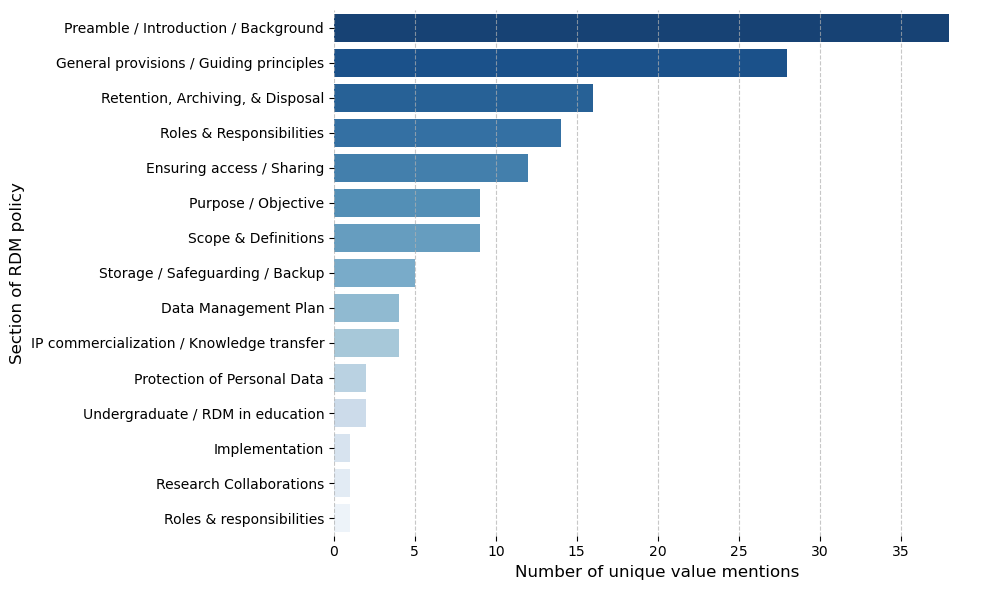

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os

# --- Group by Section ---
section_summary = (
    dataset.groupby("section")["policy_chunk"]
      .nunique()
      .reset_index()
      .sort_values("policy_chunk", ascending=False)  # largest first
)

section_summary.columns = ["Section", "Count"]

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=section_summary,
    y="Section",
    x="Count",
    palette="Blues_r"
)

#plt.title("Occurrences by Section (Value Target = Data)", fontsize=14, weight="bold")
plt.xlabel("Number of unique value mentions", fontsize=12)
plt.ylabel("Section of RDM policy", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- Save output with timestamp ---
timestamp = datetime.now().strftime("%d-%m")
output_dir = "../../docs/image_outputs"
#os.makedirs(output_dir, exist_ok=True)  # ensure folder exists
plt.savefig(f"{output_dir}/section_summary_{timestamp}.png", dpi=300, bbox_inches="tight")

plt.show()

# Slide 1 👆🏼: On what context the word "value" is found
---

## Subset of only Target Data

In [4]:
df = dataset[dataset["value_target"] == "data"].copy()

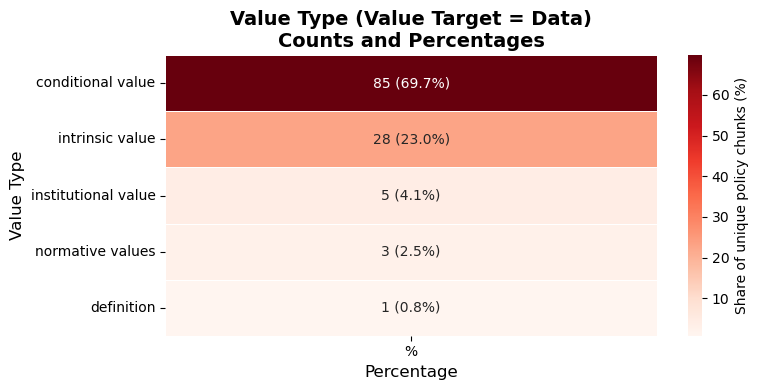

Saved to: ../../docs/image_outputs/value_type_heatmap_30-09.png


In [42]:
# --- Group by Value Type (unique policy_chunk counts) ---
total_unique = df["policy_chunk"].nunique()
summary = (
    df.groupby("value_type")["policy_chunk"]
      .nunique()
      .reset_index()
      .rename(columns={"value_type": "Value Type", "policy_chunk": "Count"})
)
summary["%"] = (summary["Count"] / total_unique * 100).round(1)

# Order: highest on top
summary = summary.sort_values("Count", ascending=False)

# --- Build 1-column heatmap data (color by %) and annotate with "Count (xx%)" ---
heat_data = summary.set_index("Value Type")[["%"]]
ann_text = summary.apply(lambda r: f"{int(r['Count'])} ({r['%']}%)", axis=1).values.reshape(-1, 1)

plt.figure(figsize=(8, max(4, 0.5 * len(summary))))
ax = sns.heatmap(
    heat_data,
    annot=ann_text, fmt="",
    cmap="Reds",                # academic red palette
    cbar_kws={"label": "Share of unique policy chunks (%)"},
    linewidths=0.5, linecolor="white"
)

plt.title("Value Type (Value Target = Data)\nCounts and Percentages", fontsize=14, weight="bold")
plt.xlabel("Percentage", fontsize=12)
plt.ylabel("Value Type", fontsize=12)

# Improve tick readability
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# --- Save output with day-month timestamp ---
timestamp = datetime.now().strftime("%d-%m")
outdir = "../../docs/image_outputs"
os.makedirs(outdir, exist_ok=True)
outfile = f"{outdir}/value_type_heatmap_{timestamp}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved to: {outfile}")

## Overlap on value propositions
explain in the slides that there are Conditional and Declarative (we are not incluing Normative values)


# Slide 2 👆🏼: What are we excluding 
Example: is valuable - normative values - university-of-cambridge.md-1

---

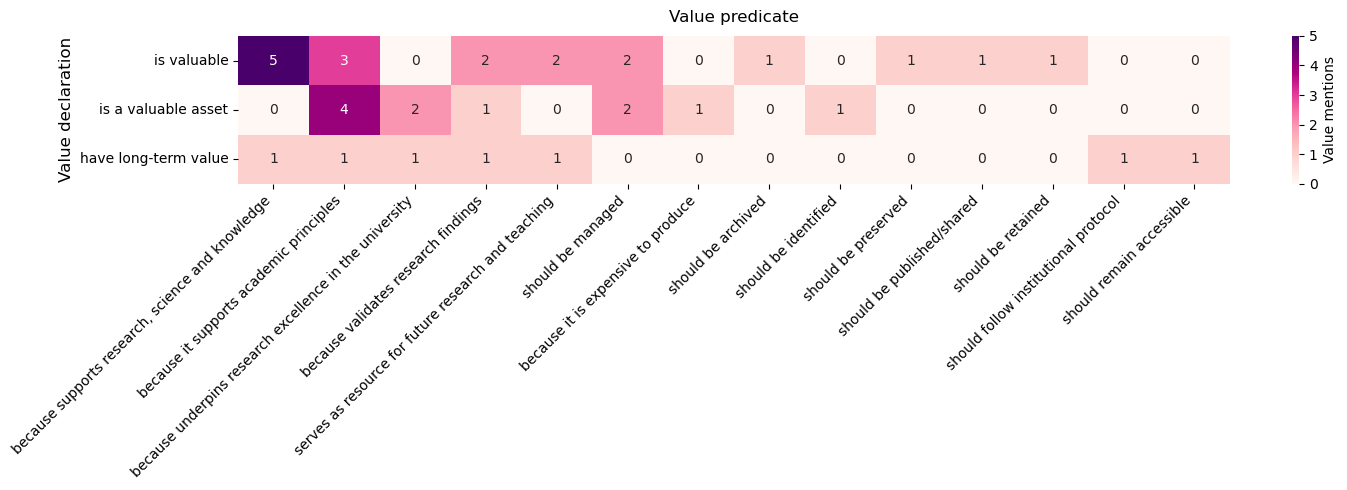

Saved to: ../../docs/image_outputs/value_declaration_action_heatmap_30-09.png


In [53]:
# --- Subset: keep intrinsic or institutional (non-conditional) ---
mask = df["value_type"].isin(["intrinsic value", "institutional value"])
df_heat = df.loc[mask].copy()

# --- Pivot table: unique policy_chunk counts ---
pivot = df_heat.pivot_table(
    index="value_condition_declaration",
    columns="value_action",
    values="policy_chunk",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# --- Order by max values (so large overlaps cluster top-left) ---
row_order = pivot.max(axis=1).sort_values(ascending=False).index
col_order = pivot.max(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

# --- Plot heatmap ---
plt.figure(figsize=(15, 5))
ax = sns.heatmap(
    pivot,
    annot=True, fmt="d",
    cmap="RdPu",
    cbar_kws={'label': 'Value mentions'}
)


plt.xlabel("Value predicate", fontsize=12, labelpad=10)
ax.xaxis.set_label_position("top")
plt.ylabel("Value declaration", fontsize=12)

# Rotate tick labels for readability
plt.xticks(rotation=45, ha="right")  # diagonal x labels
plt.yticks(rotation=0)               # horizontal y labels

plt.tight_layout()

# --- Save image with timestamp ---
timestamp = datetime.now().strftime("%d-%m")
outdir = "../../docs/image_outputs"
os.makedirs(outdir, exist_ok=True)
outfile = f"{outdir}/value_declaration_action_heatmap_{timestamp}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved to: {outfile}")

# Slide 3 👆🏼: What are the combinations in the value propositions
Example: data is valuable assent because supportts, etc - ucl.md-2

---

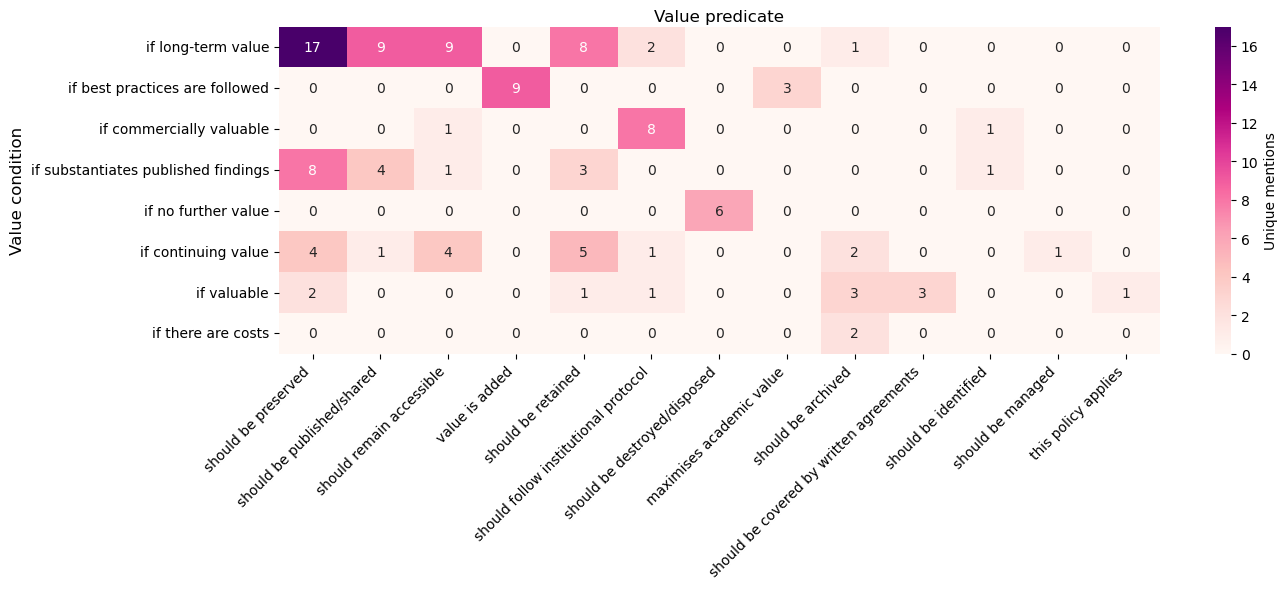

Saved to: ../../docs/image_outputs/declared_value_type_x_action_heatmap_30-09.png


In [58]:
# --- Subset: only conditional value ---
df_heat = df[df["value_type"] == "conditional value"].copy()

# --- Pivot: rows = declared value type, cols = value action; values = unique policy_chunk ---
pivot = df_heat.pivot_table(
    index="value_condition_declaration",
    columns="value_action",
    values="policy_chunk",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# --- Order by max values (strongest overlaps near top-left) ---
row_order = pivot.max(axis=1).sort_values(ascending=False).index
col_order = pivot.max(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

# --- Plot ---
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    pivot,
    annot=True, fmt="d",
    cmap="RdPu",
    cbar_kws={'label': 'Unique mentions'}
)

plt.xlabel("Value predicate", fontsize=12)
ax.xaxis.set_label_position("top")
plt.ylabel("Value condition", fontsize=12)

# Tick label readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# --- Save with timestamp ---
timestamp = datetime.now().strftime("%d-%m")
outdir = "../../docs/image_outputs"
os.makedirs(outdir, exist_ok=True)
outfile = f"{outdir}/declared_value_type_x_action_heatmap_{timestamp}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved to: {outfile}")

# Slide 4 👆🏼: What are the combinations in the value conditions
Example: if long term value should be preserved - wrexham-university.md-34  
Example: if no longer value then should be destroyed - university-of-reading.md-16

---

## Proposition short

## Beneficiaries and assessors

In [69]:
# --- Group by Value Beneficiary ---
beneficiary_summary = (
    df.groupby("value_beneficiary")["policy_chunk"]
      .nunique()
      .reset_index()
      .rename(columns={"value_beneficiary": "Value beneficiary", "policy_chunk": "Mentions"})
)

# --- Add percentages ---
total_unique = beneficiary_summary["Mentions"].sum()
beneficiary_summary["%"] = (beneficiary_summary["Mentions"] / total_unique * 100).round(2)

# --- Sort descending by count ---
beneficiary_summary = beneficiary_summary.sort_values("Mentions", ascending=False).reset_index(drop=True)

display(beneficiary_summary)

,Value beneficiary,Mentions,%
0,not specified,54,33.96
1,university,21,13.21
2,research community,20,12.58
3,society,15,9.43
4,researcher,13,8.18
5,future research,10,6.29
6,education,5,3.14
7,research,4,2.52
8,parties involved,3,1.89
9,academia,3,1.89


# Slide 5 👆🏼: Who is benefiting from the assigned value?

not specified is more than 30%
and we can see the previous examples

---

/var/folders/__/cfs5pm1964z115b7n641sb_c0000gn/T/ipykernel_82032/3869686695.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


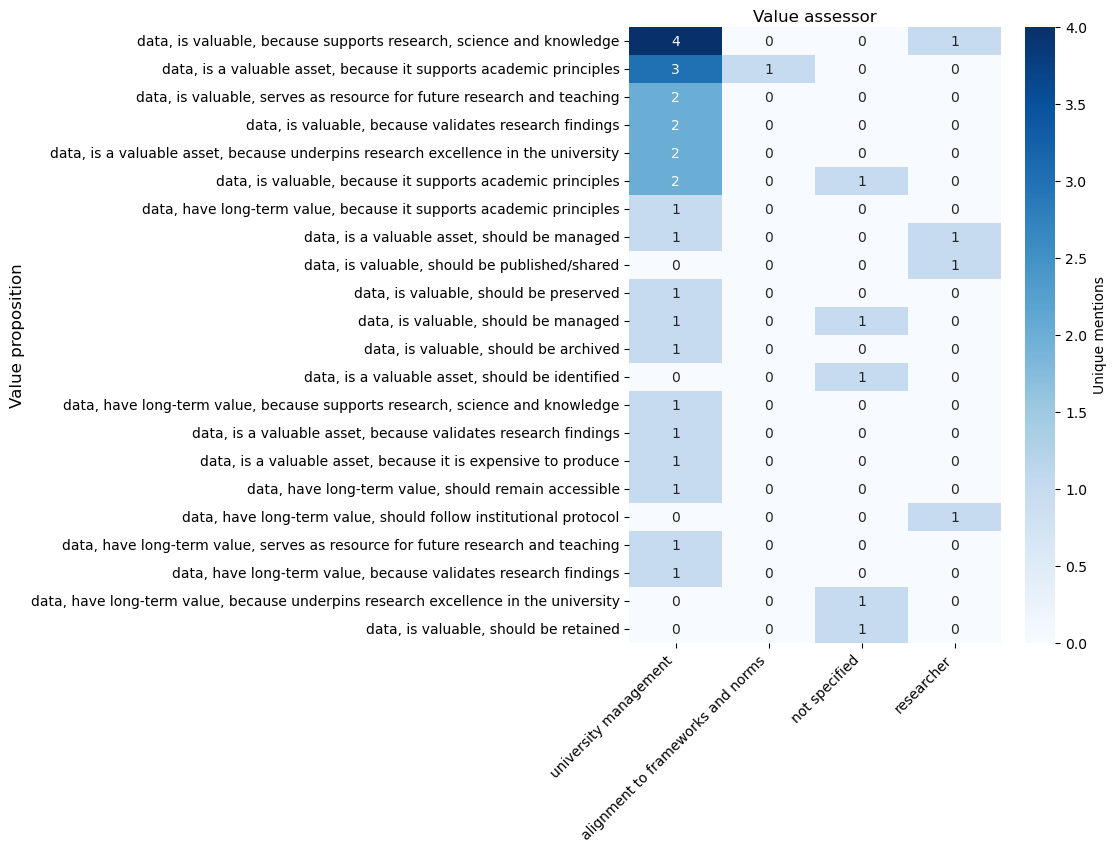

Saved to: ../../docs/image_outputs/vp_short_x_assessor_heatmap_30-09.png


In [77]:
# --- Subset: institutional or intrinsic value ---
df_sub = df[df["value_type"].isin(["institutional value", "intrinsic value"])].copy()

# --- Identify top 10 Value Proposition Short ---
top10_vp = (
    df_sub.groupby("value_proposition_short")["policy_chunk"]
    .nunique()
    .sort_values(ascending=False)
    #.head(15)
    .index
)

# --- Filter only top 10 ---
df_top = df_sub[df_sub["value_proposition_short"].isin(top10_vp)].copy()

# --- Pivot table ---
pivot = df_top.pivot_table(
    index="value_proposition_short",
    columns="value_assessor",
    values="policy_chunk",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# --- Order rows and columns so strongest overlaps are top-left ---
row_order = pivot.max(axis=1).sort_values(ascending=False).index
col_order = pivot.max(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

# --- Plot heatmap ---
plt.figure(figsize=(6, 8))
ax = sns.heatmap(
    pivot,
    annot=True, fmt="d",
    cmap="Blues",   # academic blue for non-conditional values
    cbar_kws={'label': 'Unique mentions'}
)

plt.xlabel("Value assessor", fontsize=12)
ax.xaxis.set_label_position("top")
plt.ylabel("Value proposition", fontsize=12)

# Rotate tick labels
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# --- Save image with timestamp ---
timestamp = datetime.now().strftime("%d-%m")
outdir = "../../docs/image_outputs"
os.makedirs(outdir, exist_ok=True)
outfile = f"{outdir}/vp_short_x_assessor_heatmap_{timestamp}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved to: {outfile}")

# Slide 6 👆🏼: Who is asseing the value?

example university-of-london.md-8 or university-of-oxford.md-0  
not specified	os 30% to start with

---